# SWA Methodology and comparisons

This notebook shows the training flow for the Challenge, I'll compare **ResNet18**, **DenseNet121** and **EfficientNet** with Yan's SWA (Stochastic weight averaging), as well as the stacking ensemble method. I also made sure to give the option to export tables and figures!

important Vars to keep a look out for:
- `METHODOLOGY_RUN_TRAINING=0` loads saved artifacts instead of retraining.
- `METHODOLOGY_FAST_MODE=1` runs a small smoke-test configuration.
- `METHODOLOGY_SAVE_FIGURES=0` skips writing figures to disk.

**LLM disclaimer:**

- I needed some help with the caching for speedup and the pin memory!
    we havent covered these things in any courses but they seemed very popular when checking similar challenges!

In [1]:
from __future__ import annotations

import os
import random
import sys
from pathlib import Path

CACHE_ROOT = Path(os.environ.get('TMPDIR', '/tmp')) / 'iivp_methodology_cache'
MPL_CACHE_ROOT = CACHE_ROOT / 'matplotlib'
MPL_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('XDG_CACHE_HOME', str(CACHE_ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from PIL import Image
from sklearn.metrics import confusion_matrix
from torchvision import transforms

PROJECT_ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'src').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the project root from the current working directory.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.dataset.augmentation import Augmentation
from src.models.ensemble_pipeline import (
    collect_oof_meta_features,
    default_data_transforms,
    run_stacking_meta_cv,
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
pd.options.display.float_format = '{:.4f}'.format

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/Image&VideoProcessing/Challenge


In [2]:
def env_flag(name: str, default: bool) -> bool:
    raw_value = os.getenv(name)
    if raw_value is None:
        return default
    return raw_value.strip().lower() in {'1', 'true', 'yes', 'on'}


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def select_device() -> tuple[torch.device, str]:
    if torch.backends.mps.is_available():
        return torch.device('mps'), 'MPS is availlable, so training will use the GPU backend.'
    if torch.cuda.is_available():
        return torch.device('cuda'), 'CUDA is available, so training will use the CUDA backend.'
    return torch.device('cpu'), 'No supported GPU backend is available, so the notebook is running on CPU.'


def normalize_fold_path(raw_path: str, project_root: Path) -> str:
    normalized = str(raw_path).replace('\\\\', '/')
    path_obj = Path(normalized)
    candidates = []

    if path_obj.is_absolute():
        candidates.append(path_obj)
    candidates.append(project_root / normalized)

    if normalized.startswith('data/train/train/'):
        suffix = Path(normalized).parts[3:]
        candidates.append(project_root / 'data' / 'iivp-2026-challenge' / 'train' / 'train' / Path(*suffix))
    if normalized.startswith('data/test/test/'):
        suffix = Path(normalized).parts[3:]
        candidates.append(project_root / 'data' / 'iivp-2026-challenge' / 'test' / 'test' / Path(*suffix))

    for candidate in candidates:
        if candidate.exists():
            return str(candidate.resolve())

    return str((project_root / normalized).resolve()) if not path_obj.is_absolute() else str(path_obj)


def load_folds_dataframe(project_root: Path) -> pd.DataFrame:
    primary_path = project_root / 'data' / 'folds.csv'
    legacy_path = project_root / 'folds' / 'train_folds_5.csv'

    if primary_path.exists():
        df = pd.read_csv(primary_path)
    elif legacy_path.exists():
        df = pd.read_csv(legacy_path)
    else:
        raise FileNotFoundError('Could not find either data/folds.csv or folds/train_folds_5.csv.')

    df = df.copy()
    df['path'] = df['path'].map(lambda value: normalize_fold_path(value, project_root))
    return df


def validate_full_folds_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) != 17_000:
        raise ValueError(f'Expected 17,000 training samples, found {len(df):,}.')
    if df['label'].nunique() != 10:
        raise ValueError(f'Expected 10 classes, found {df["label"].nunique()}.')

    expected_folds = {0, 1, 2, 3, 4}
    observed_folds = set(df['fold'].unique().tolist())
    if observed_folds != expected_folds:
        raise ValueError(f'Expected folds {sorted(expected_folds)}, found {sorted(observed_folds)}.')

    missing_paths = df.loc[~df['path'].map(lambda value: Path(value).exists()), 'path']
    if not missing_paths.empty:
        raise FileNotFoundError(f'Found {len(missing_paths):,} paths that do not exist. Example: {missing_paths.iloc[0]}')

    distribution = (
        df.groupby(['fold', 'label'])
        .size()
        .rename('count')
        .reset_index()
        .sort_values(['fold', 'label'])
        .reset_index(drop=True)
    )
    return distribution


def prepare_experiment_dataframe(
    df: pd.DataFrame,
    *,
    fast_mode: bool,
    full_folds: list[int],
    fast_folds: list[int],
    fast_samples_per_label_per_fold: int,
) -> tuple[pd.DataFrame, list[int]]:
    selected_folds = fast_folds if fast_mode else full_folds
    filtered = df[df['fold'].isin(selected_folds)].copy()

    if fast_mode:
        filtered = (
            filtered.sort_values(['fold', 'label', 'path'])
            .groupby(['fold', 'label'], group_keys=False)
            .head(fast_samples_per_label_per_fold)
            .reset_index(drop=True)
        )
    else:
        filtered = filtered.reset_index(drop=True)

    return filtered, selected_folds


def maybe_save_figure(fig: plt.Figure, filename: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches='tight')


def history_values(history: object, key: str) -> list[float]:
    if hasattr(history, key):
        return list(getattr(history, key))
    return list(history[key])


def build_base_history_frame(base_model_histories: dict[str, list[dict[str, list[float]]]], folds: list[int]) -> pd.DataFrame:
    rows = []
    for model_name, histories in base_model_histories.items():
        if len(histories) != len(folds):
            raise ValueError(f'History count for {model_name} does not match the fold list.')
        for fold, history in zip(folds, histories):
            epoch_count = len(history['train_loss'])
            for epoch_index in range(epoch_count):
                rows.append(
                    {
                        'model': model_name,
                        'fold': fold,
                        'epoch': epoch_index + 1,
                        'train_loss': history['train_loss'][epoch_index],
                        'train_acc': history['train_acc'][epoch_index],
                        'val_loss': history['val_loss'][epoch_index],
                        'val_acc': history['val_acc'][epoch_index],
                    }
                )
    return pd.DataFrame(rows)


def build_meta_history_frame(meta_fit_histories: dict[int, object]) -> pd.DataFrame:
    rows = []
    for fold, history in sorted(meta_fit_histories.items()):
        train_loss = history_values(history, 'train_loss')
        train_accuracy = history_values(history, 'train_accuracy')
        for epoch_index in range(len(train_loss)):
            rows.append(
                {
                    'fold': fold,
                    'epoch': epoch_index + 1,
                    'train_loss': train_loss[epoch_index],
                    'train_accuracy': train_accuracy[epoch_index],
                }
            )
    return pd.DataFrame(rows)


def serialize_meta_fit_histories(meta_fit_histories: dict[int, object]) -> dict[int, dict[str, list[float]]]:
    return {
        int(fold): {
            'train_loss': history_values(history, 'train_loss'),
            'train_accuracy': history_values(history, 'train_accuracy'),
        }
        for fold, history in meta_fit_histories.items()
    }


def build_summary_table(
    base_model_accuracies: dict[str, list[float]],
    stacking_fold_accuracies: list[float],
) -> pd.DataFrame:
    rows = []
    for model_name, scores in base_model_accuracies.items():
        score_array = np.asarray(scores, dtype=float)
        rows.append(
            {
                'model': model_name,
                'mean_accuracy': score_array.mean(),
                'std_accuracy': score_array.std(ddof=0),
                'min_accuracy': score_array.min(),
                'max_accuracy': score_array.max(),
                'n_folds': len(score_array),
                'fold_accuracies': ', '.join(f'{score:.4f}' for score in score_array),
            }
        )

    stacking_array = np.asarray(stacking_fold_accuracies, dtype=float)
    rows.append(
        {
            'model': 'Stacking Ensemble',
            'mean_accuracy': stacking_array.mean(),
            'std_accuracy': stacking_array.std(ddof=0),
            'min_accuracy': stacking_array.min(),
            'max_accuracy': stacking_array.max(),
            'n_folds': len(stacking_array),
            'fold_accuracies': ', '.join(f'{score:.4f}' for score in stacking_array),
        }
    )

    return pd.DataFrame(rows).sort_values('mean_accuracy', ascending=False).reset_index(drop=True)


def plot_history_band(history_df: pd.DataFrame, metric: str, ax: plt.Axes, title: str, ylabel: str) -> None:
    for model_name, model_df in history_df.groupby('model'):
        summary = (
            model_df.groupby('epoch')[metric]
            .agg(['mean', 'std'])
            .reset_index()
            .sort_values('epoch')
        )
        std = summary['std'].fillna(0.0)
        ax.plot(summary['epoch'], summary['mean'], label=model_name)
        ax.fill_between(summary['epoch'], summary['mean'] - std, summary['mean'] + std, alpha=0.18)

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)


def plot_meta_history_band(meta_history_df: pd.DataFrame, metric: str, ax: plt.Axes, title: str, ylabel: str) -> None:
    summary = (
        meta_history_df.groupby('epoch')[metric]
        .agg(['mean', 'std'])
        .reset_index()
        .sort_values('epoch')
    )
    std = summary['std'].fillna(0.0)
    ax.plot(summary['epoch'], summary['mean'], color='tab:blue')
    ax.fill_between(summary['epoch'], summary['mean'] - std, summary['mean'] + std, alpha=0.2, color='tab:blue')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)

In [3]:
RUN_TRAINING = False
FAST_MODE = False
SAVE_FIGURES = True

SEED = 42069
FULL_FOLDS = [0, 1, 2, 3, 4]
FAST_FOLDS = [0, 1]
FAST_SAMPLES_PER_LABEL_PER_FOLD = 10
BASE_MODEL_NAMES = ['ResNet18 + SWA', 'DenseNet121 +SWA', 'EfficientNet + SWA']
NUM_CLASSES = 10
TRAIN_AUGMENTATION_PROB = 0.4
BATCH_SIZE = 32 if FAST_MODE else 64
EPOCHS = 2 if FAST_MODE else 15
META_EPOCHS = 2 if FAST_MODE else 10

TRAINER_KWARGS = {
    'use_swa': True,
    'swa_start_epoch': 1 if FAST_MODE else 10,
    'swa_lr': 1e-4,
}

FIGURE_DIR = PROJECT_ROOT / 'experiments' / 'figures' / 'methodology'
ARTIFACT_DIR = PROJECT_ROOT / 'experiments' / 'artifacts' / 'methodology_swa_notebook'
ARTIFACT_PREFIX = 'fast' if FAST_MODE else 'full'
RESULTS_BUNDLE_PATH = ARTIFACT_DIR / f'{ARTIFACT_PREFIX}_results_bundle.pt'
SUMMARY_CSV_PATH = ARTIFACT_DIR / f'{ARTIFACT_PREFIX}_summary_metrics.csv'
BASE_HISTORY_CSV_PATH = ARTIFACT_DIR / f'{ARTIFACT_PREFIX}_base_model_histories.csv'
STACKING_HISTORY_CSV_PATH = ARTIFACT_DIR / f'{ARTIFACT_PREFIX}_stacking_meta_histories.csv'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# I needed a bit of the help of an LLM for this part!
seed_everything(SEED)
device, device_note = select_device()
PIN_MEMORY = device.type == 'cuda'
NUM_WORKERS = 0 if device.type in {'cpu', 'mps'} else min(4, os.cpu_count() or 1)
STACKING_META_FIT_KWARGS = {
    'epochs': META_EPOCHS,
    'batch_size': BATCH_SIZE,
    'verbose': False,
}
# -------

print(device)

mps


## Data Setup

The canonical fold file is `data/folds.csv`. If it is missing, the notebook falls back to the legacy `folds/train_folds_5.csv` file and normalizes its Windows-style paths in memory.

In [4]:
folds_full = load_folds_dataframe(PROJECT_ROOT)
full_distribution = validate_full_folds_dataframe(folds_full)

print(f'Total samples: {len(folds_full):,}')
print(f'Unique classes: {folds_full["label"].nunique()}')
print(f'Folds: {sorted(folds_full["fold"].unique().tolist())}')
display(folds_full.head())
display(full_distribution.head(15))

Total samples: 17,000
Unique classes: 10
Folds: [0, 1, 2, 3, 4]


,path,label,fold
0,/Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...,0,4
1,/Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...,0,0
2,/Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...,0,0
3,/Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...,0,1
4,/Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/...,0,3


,fold,label,count
0,0,0,340
1,0,1,340
2,0,2,340
3,0,3,340
4,0,4,340
5,0,5,340
6,0,6,340
7,0,7,340
8,0,8,340
9,0,9,340


In [5]:
experiment_df, selected_folds = prepare_experiment_dataframe(
    folds_full,
    fast_mode=FAST_MODE,
    full_folds=FULL_FOLDS,
    fast_folds=FAST_FOLDS,
    fast_samples_per_label_per_fold=FAST_SAMPLES_PER_LABEL_PER_FOLD,
)

experiment_distribution = (
    experiment_df.groupby(['fold', 'label'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['fold', 'label'])
    .reset_index(drop=True)
)


display(experiment_distribution.head(20))

print(
        f"experiment subset \n"
        f"- Selected folds: `{selected_folds}`  \n"
        f"- Samples used in this run: `{len(experiment_df):,}`"
    )

display(experiment_distribution.head(20))

,fold,label,count
0,0,0,340
1,0,1,340
2,0,2,340
3,0,3,340
4,0,4,340
5,0,5,340
6,0,6,340
7,0,7,340
8,0,8,340
9,0,9,340


experiment subset 
- Selected folds: `[0, 1, 2, 3, 4]`  
- Samples used in this run: `17,000`


,fold,label,count
0,0,0,340
1,0,1,340
2,0,2,340
3,0,3,340
4,0,4,340
5,0,5,340
6,0,6,340
7,0,7,340
8,0,8,340
9,0,9,340


## Methodology Figures

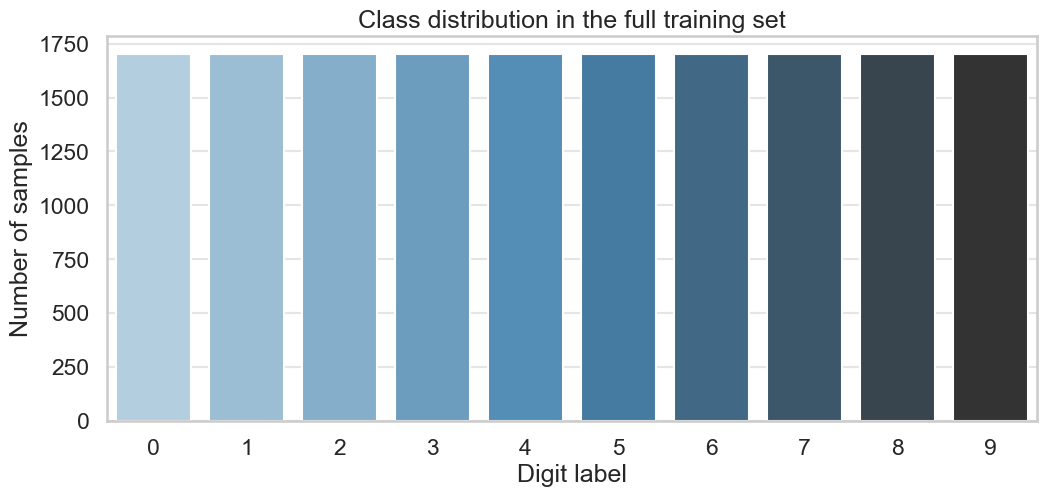

In [6]:
class_counts = folds_full['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='Blues_d', legend=False, ax=ax)
ax.set_title('Class distribution in the full training set')
ax.set_xlabel('Digit label')
ax.set_ylabel('Number of samples')
maybe_save_figure(fig, 'class_distribution.png')
plt.show()

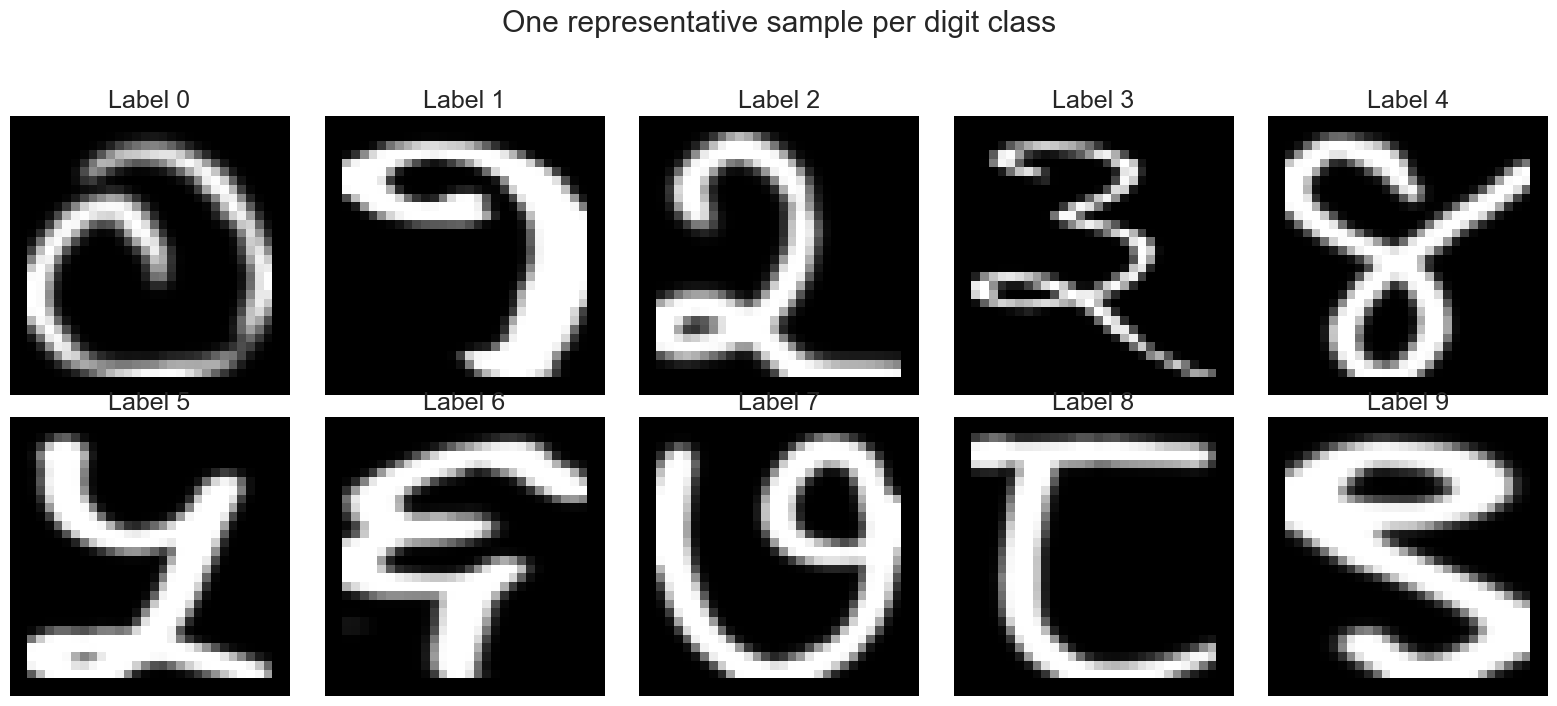

In [7]:
sample_rows = (
    folds_full.sort_values(['label', 'path'])
    .groupby('label', as_index=False)
    .first()
)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    image = Image.open(row['path']).convert('L')
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label {row['label']}")
    ax.axis('off')

fig.suptitle('One representative sample per digit class', y=1.02)
fig.tight_layout()
maybe_save_figure(fig, 'digit_sample_grid.png')
plt.show()

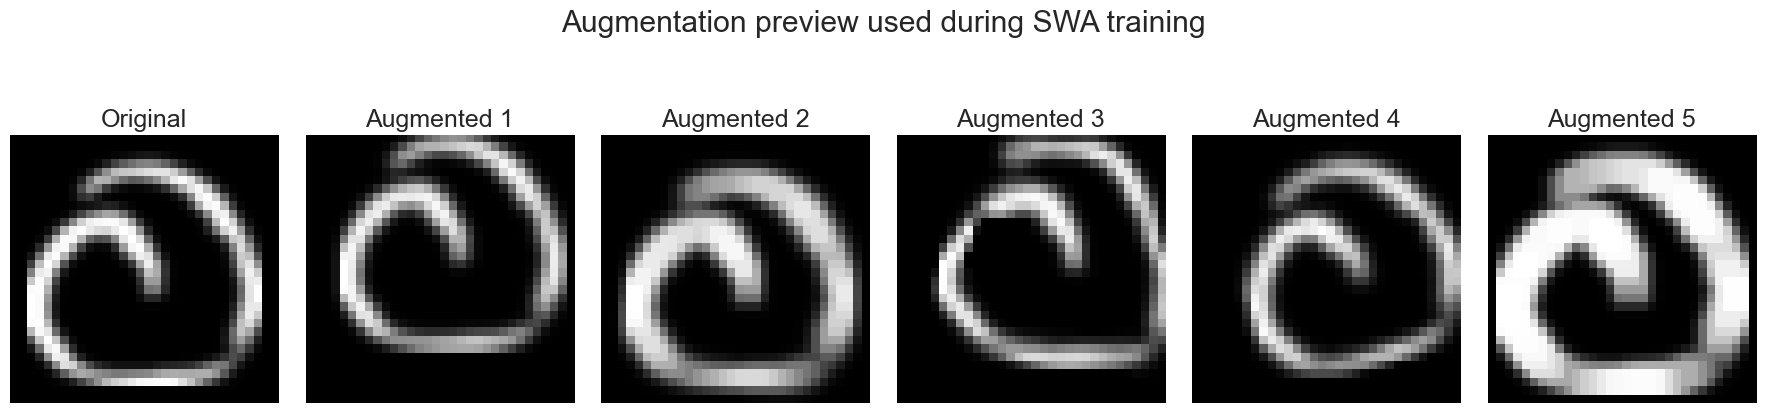

In [8]:
preview_row = folds_full.sort_values(['label', 'path']).iloc[0]
preview_image = Image.open(preview_row['path']).convert('L')
preview_transform = transforms.Compose([
    Augmentation(prob=TRAIN_AUGMENTATION_PROB),
    transforms.RandomApply([transforms.ElasticTransform(alpha=34.0, sigma=4.0)], p=0.4),
])

preview_images = [preview_image] + [preview_transform(preview_image.copy()) for _ in range(5)]
preview_titles = ['Original'] + [f'Augmented {index}' for index in range(1, 6)]

fig, axes = plt.subplots(1, len(preview_images), figsize=(18, 4))
for ax, title, image in zip(axes, preview_titles, preview_images):
    ax.imshow(np.asarray(image), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

fig.suptitle('Augmentation preview used during SWA training', y=1.08)
fig.tight_layout()
maybe_save_figure(fig, 'augmentation_preview.png')
plt.show()

## Training and Artifact Export

This section either trains the models and writes fresh artifacts, or reloads the saved bundle if `RUN_TRAINING` is disabled.

In [9]:
training_transforms = default_data_transforms(train_augmentation_prob=TRAIN_AUGMENTATION_PROB)

if RUN_TRAINING:
    oof_collection = collect_oof_meta_features(
        experiment_df,
        base_model_names=BASE_MODEL_NAMES,
        folds=selected_folds,
        num_classes=NUM_CLASSES,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        num_workers=NUM_WORKERS,
        data_transforms=training_transforms,
        device=device,
        trainer_kwargs=TRAINER_KWARGS,
        pin_memory=PIN_MEMORY,
    )
    stacking_meta_result = run_stacking_meta_cv(
        oof_collection,
        device=device,
        folds=selected_folds,
        meta_fit_kwargs=STACKING_META_FIT_KWARGS,
    )

    base_history_df = build_base_history_frame(oof_collection.base_model_histories, selected_folds)
    stacking_history_df = build_meta_history_frame(stacking_meta_result.meta_fit_histories)
    summary_df = build_summary_table(oof_collection.base_model_accuracies, stacking_meta_result.fold_accuracies)

    results_bundle = {
        'selected_folds': list(selected_folds),
        'base_model_names': list(BASE_MODEL_NAMES),
        'base_model_accuracies': oof_collection.base_model_accuracies,
        'base_model_histories': oof_collection.base_model_histories,
        'fold_sample_indices': oof_collection.fold_sample_indices,
        'meta_features': oof_collection.meta_features.cpu(),
        'targets': oof_collection.targets.cpu(),
        'sample_indices': oof_collection.sample_indices.cpu(),
        'stacking_fold_accuracies': stacking_meta_result.fold_accuracies,
        'stacking_oof_predictions': stacking_meta_result.oof_predictions.cpu(),
        'stacking_oof_targets': stacking_meta_result.oof_targets.cpu(),
        'stacking_sample_indices': list(stacking_meta_result.sample_indices),
        'stacking_meta_fit_histories': serialize_meta_fit_histories(stacking_meta_result.meta_fit_histories),
        'stacking_meta_train_sample_indices_by_fold': stacking_meta_result.meta_train_sample_indices_by_fold,
        'stacking_meta_validation_sample_indices_by_fold': stacking_meta_result.meta_validation_sample_indices_by_fold,
        'summary_rows': summary_df.to_dict(orient='records'),
        'config': {
            'fast_mode': FAST_MODE,
            'batch_size': BATCH_SIZE,
            'epochs': EPOCHS,
            'meta_epochs': META_EPOCHS,
            'device': device.type,
            'pin_memory': PIN_MEMORY,
            'num_workers': NUM_WORKERS,
            'trainer_kwargs': TRAINER_KWARGS,
        },
    }

    torch.save(results_bundle, RESULTS_BUNDLE_PATH)
    summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
    base_history_df.to_csv(BASE_HISTORY_CSV_PATH, index=False)
    stacking_history_df.to_csv(STACKING_HISTORY_CSV_PATH, index=False)
else:
    if not RESULTS_BUNDLE_PATH.exists():
        raise FileNotFoundError(
            f' Couldnt find the results at: {RESULTS_BUNDLE_PATH}. Worst case rerun the notebook with training = True'
        )

    results_bundle = torch.load(RESULTS_BUNDLE_PATH, map_location='cpu', weights_only=False)
    selected_folds = list(results_bundle['selected_folds'])
    summary_df = pd.DataFrame(results_bundle['summary_rows'])
    base_history_df = pd.read_csv(BASE_HISTORY_CSV_PATH)
    stacking_history_df = pd.read_csv(STACKING_HISTORY_CSV_PATH)

base_model_accuracies = results_bundle['base_model_accuracies']
stacking_fold_accuracies = results_bundle['stacking_fold_accuracies']
stacking_oof_predictions = torch.as_tensor(results_bundle['stacking_oof_predictions']).cpu()
stacking_oof_targets = torch.as_tensor(results_bundle['stacking_oof_targets']).cpu()

summary_df = summary_df.sort_values('mean_accuracy', ascending=False).reset_index(drop=True)
display(summary_df)
print(f'Saved summary table to: {SUMMARY_CSV_PATH}')
print(f'Saved results bundle to: {RESULTS_BUNDLE_PATH}')

,model,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,n_folds,fold_accuracies
0,ResNet18,0.9995,0.0003,0.9991,1.0000,5,"0.9994, 0.9997, 0.9994, 0.9991, 1.0000"
1,Stacking Ensemble,0.9991,0.0005,0.9985,1.0000,5,"0.9991, 0.9991, 0.9988, 0.9985, 1.0000"
2,DenseNet121,0.9991,0.0004,0.9982,0.9994,5,"0.9991, 0.9994, 0.9991, 0.9982, 0.9994"
3,EfficientNet,0.9989,0.0005,0.9979,0.9994,5,"0.9991, 0.9988, 0.9979, 0.9991, 0.9994"


Saved summary table to: /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/Image&VideoProcessing/Challenge/experiments/artifacts/methodology_swa_mps/full_summary_metrics.csv
Saved results bundle to: /Users/nickgrebe/Desktop/DSAI_YEAR2/Periode 5/Image&VideoProcessing/Challenge/experiments/artifacts/methodology_swa_mps/full_results_bundle.pt


## Learning Curves

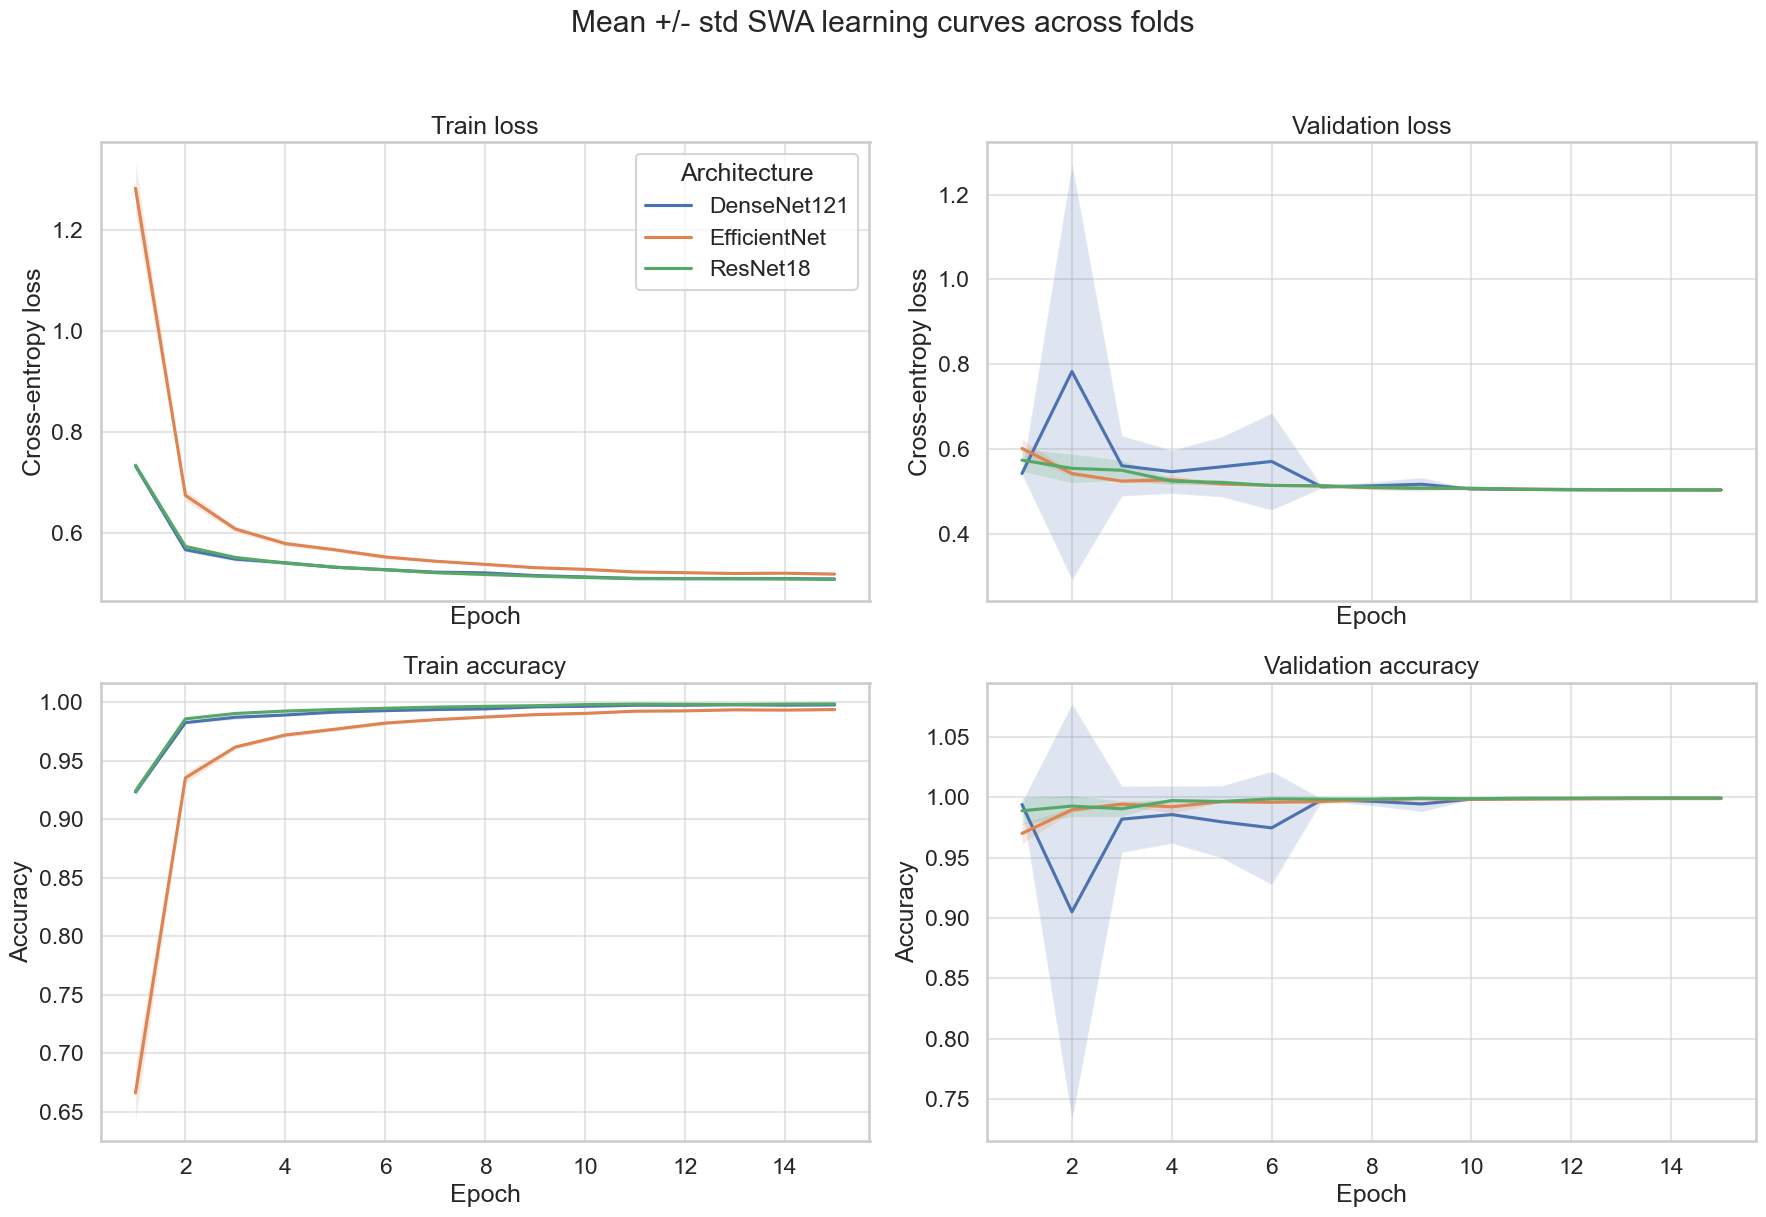

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
metric_specs = [
    ('train_loss', 'Train loss', 'Cross-entropy loss'),
    ('val_loss', 'Validation loss', 'Cross-entropy loss'),
    ('train_acc', 'Train accuracy', 'Accuracy'),
    ('val_acc', 'Validation accuracy', 'Accuracy'),
]

for ax, (metric, title, ylabel) in zip(axes.flat, metric_specs):
    plot_history_band(base_history_df, metric, ax, title, ylabel)

axes[0, 0].legend(title='Architecture')
fig.suptitle('Mean +/- std SWA learning curves across folds', y=1.02)
fig.tight_layout()
maybe_save_figure(fig, 'base_model_learning_curves.png')
plt.show()

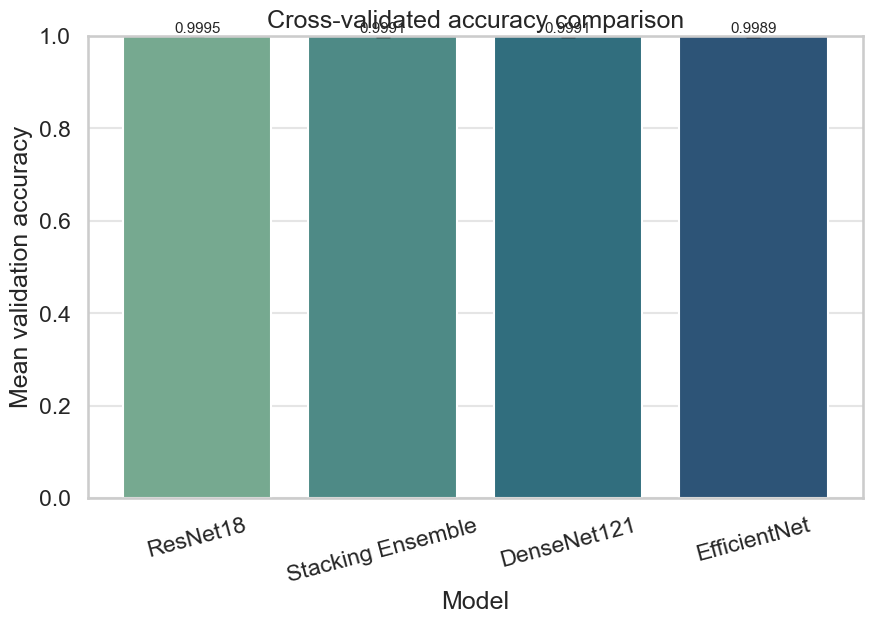

In [11]:
comparison_df = summary_df.copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=comparison_df, x='model', y='mean_accuracy', hue='model', dodge=False, palette='crest', legend=False, ax=ax)
ax.errorbar(
    x=np.arange(len(comparison_df)),
    y=comparison_df['mean_accuracy'],
    yerr=comparison_df['std_accuracy'],
    fmt='none',
    color='black',
    capsize=5,
    linewidth=1.5,
)
for index, value in enumerate(comparison_df['mean_accuracy']):
    ax.text(index, value + 0.002, f'{value:.4f}', ha='center', va='bottom', fontsize=11)
ax.set_title('Cross-validated accuracy comparison')
ax.set_xlabel('Model')
ax.set_ylabel('Mean validation accuracy')
ax.set_ylim(0.0, min(1.0, comparison_df['mean_accuracy'].max() + 0.05))
ax.tick_params(axis='x', rotation=15)
maybe_save_figure(fig, 'cv_accuracy_comparison.png')
plt.show()

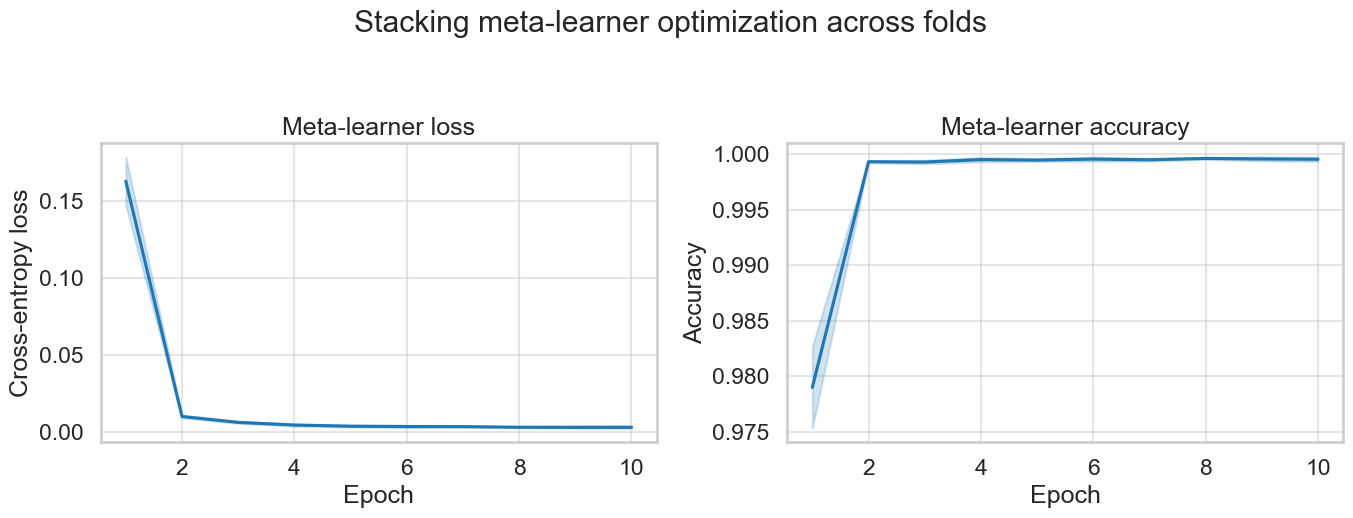

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
plot_meta_history_band(stacking_history_df, 'train_loss', axes[0], 'Meta-learner loss', 'Cross-entropy loss')
plot_meta_history_band(stacking_history_df, 'train_accuracy', axes[1], 'Meta-learner accuracy', 'Accuracy')
fig.suptitle('Stacking meta-learner optimization across folds', y=1.05)
fig.tight_layout()
maybe_save_figure(fig, 'stacking_meta_history.png')
plt.show()

## Ensemble Diagnostics

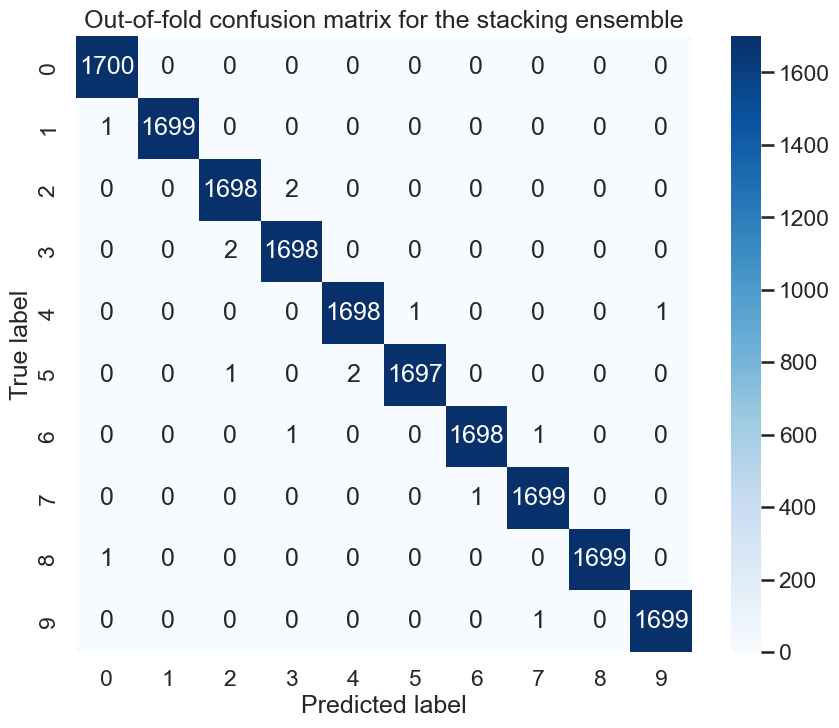

In [13]:
labels = list(range(NUM_CLASSES))
conf_mat = confusion_matrix(stacking_oof_targets.numpy(), stacking_oof_predictions.numpy(), labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=True, square=True, ax=ax)
ax.set_title('Out-of-fold confusion matrix for the stacking ensemble')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
maybe_save_figure(fig, 'stacking_confusion_matrix.png')
plt.show()

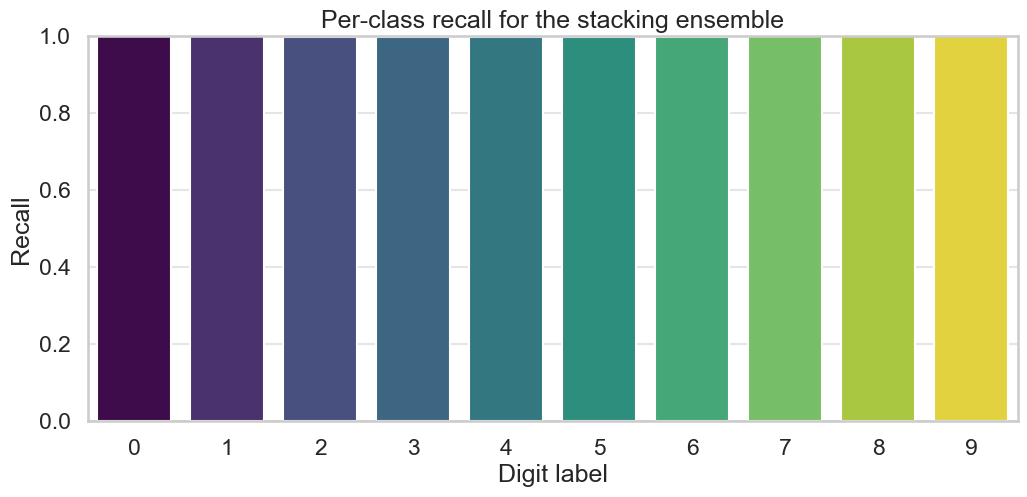

,label,recall
0,0,1.0000
1,1,0.9994
2,2,0.9988
3,3,0.9988
4,4,0.9988
5,5,0.9982
6,6,0.9988
7,7,0.9994
8,8,0.9994
9,9,0.9994


In [14]:
per_class_recall = np.divide(
    np.diag(conf_mat),
    conf_mat.sum(axis=1),
    out=np.zeros(len(labels), dtype=float),
    where=conf_mat.sum(axis=1) > 0,
)
recall_df = pd.DataFrame({'label': labels, 'recall': per_class_recall})

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=recall_df, x='label', y='recall', hue='label', palette='viridis', legend=False, ax=ax)
ax.set_title('Per-class recall for the stacking ensemble')
ax.set_xlabel('Digit label')
ax.set_ylabel('Recall')
ax.set_ylim(0.0, 1.0)
maybe_save_figure(fig, 'stacking_per_class_recall.png')
plt.show()

display(recall_df)

## Summary Table

In [15]:
display(summary_df)

,model,mean_accuracy,std_accuracy,min_accuracy,max_accuracy,n_folds,fold_accuracies
0,ResNet18,0.9995,0.0003,0.9991,1.0000,5,"0.9994, 0.9997, 0.9994, 0.9991, 1.0000"
1,Stacking Ensemble,0.9991,0.0005,0.9985,1.0000,5,"0.9991, 0.9991, 0.9988, 0.9985, 1.0000"
2,DenseNet121,0.9991,0.0004,0.9982,0.9994,5,"0.9991, 0.9994, 0.9991, 0.9982, 0.9994"
3,EfficientNet,0.9989,0.0005,0.9979,0.9994,5,"0.9991, 0.9988, 0.9979, 0.9991, 0.9994"
